# Target Variable Analysis in the Dengue Fever Competition

In this notebook, 
- We analyse the target variable distributions for two different cities,
- We also check the correlation of the target variable to the features.

In [1]:
# Imporet train data and target
import pandas as pd
data=pd.read_csv("../src/data/raw/dengue_features_train.csv") # Train data
target=pd.read_csv("../src/data/raw/dengue_labels_train.csv") # Labels

In [2]:
# Display rows from the dataframe
data.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [3]:
# Display dataframe info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   1456 non-null   object 
 1   year                                   1456 non-null   int64  
 2   weekofyear                             1456 non-null   int64  
 3   week_start_date                        1456 non-null   object 
 4   ndvi_ne                                1262 non-null   float64
 5   ndvi_nw                                1404 non-null   float64
 6   ndvi_se                                1434 non-null   float64
 7   ndvi_sw                                1434 non-null   float64
 8   precipitation_amt_mm                   1443 non-null   float64
 9   reanalysis_air_temp_k                  1446 non-null   float64
 10  reanalysis_avg_temp_k                  1446 non-null   float64
 11  rean

In [10]:
import pandas as pd

# assume df is your DataFrame, and 'city' is the city column

# Create a dict mapping each city → Series of % missing per column
missing_by_city = {
    city: (group.isnull().mean() * 100).sort_values(ascending=False)
    for city, group in data.groupby('city')
}

# Example: print the Series for one city
city_name = list(missing_by_city.keys())[0]
print(f"Missing % for {city_name}:\n", missing_by_city[city_name])
# Example: print the Series for one city
print()
city_name = list(missing_by_city.keys())[1]
print(f"Missing % for {city_name}:\n", missing_by_city[city_name])

Missing % for iq:
 station_avg_temp_c                       7.115385
station_diur_temp_rng_c                  7.115385
station_precip_mm                        3.076923
station_max_temp_c                       2.692308
station_min_temp_c                       1.538462
reanalysis_air_temp_k                    0.769231
precipitation_amt_mm                     0.769231
reanalysis_avg_temp_k                    0.769231
reanalysis_relative_humidity_percent     0.769231
reanalysis_precip_amt_kg_per_m2          0.769231
reanalysis_min_air_temp_k                0.769231
reanalysis_max_air_temp_k                0.769231
reanalysis_dew_point_temp_k              0.769231
reanalysis_tdtr_k                        0.769231
reanalysis_sat_precip_amt_mm             0.769231
reanalysis_specific_humidity_g_per_kg    0.769231
ndvi_ne                                  0.576923
ndvi_nw                                  0.576923
ndvi_se                                  0.576923
ndvi_sw                        

In [6]:
# Display rows from the dataframe
target.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,4
1,sj,1990,19,5
2,sj,1990,20,4
3,sj,1990,21,3
4,sj,1990,22,6


In [7]:
# Display dataframe info
target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   city         1456 non-null   object
 1   year         1456 non-null   int64 
 2   weekofyear   1456 non-null   int64 
 3   total_cases  1456 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 45.6+ KB


In [15]:
# Merge train data and labels for analysis
df_merged = pd.merge(data, target, on=['city', 'year', 'weekofyear'], how='inner')
df_merged.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


In [9]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   1456 non-null   object 
 1   year                                   1456 non-null   int64  
 2   weekofyear                             1456 non-null   int64  
 3   week_start_date                        1456 non-null   object 
 4   ndvi_ne                                1262 non-null   float64
 5   ndvi_nw                                1404 non-null   float64
 6   ndvi_se                                1434 non-null   float64
 7   ndvi_sw                                1434 non-null   float64
 8   precipitation_amt_mm                   1443 non-null   float64
 9   reanalysis_air_temp_k                  1446 non-null   float64
 10  reanalysis_avg_temp_k                  1446 non-null   float64
 11  rean

## Target Variable Distribution

/tmp/ipykernel_22743/3141510970.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


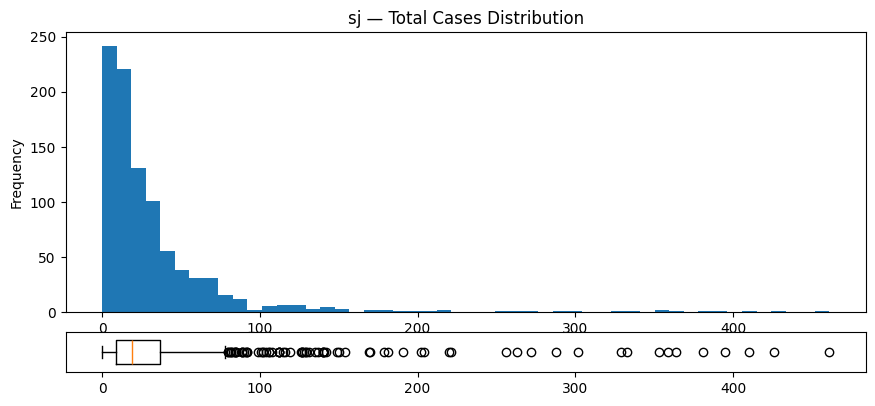

/tmp/ipykernel_22743/3141510970.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


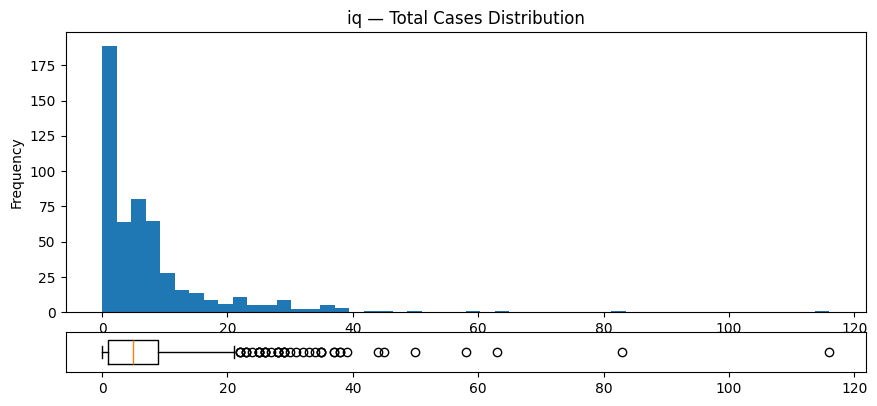

In [14]:
import matplotlib.pyplot as plt

# Make sure 'city' is treated as categorical
cities = df_merged['city'].unique()

for city in cities:
    data = df_merged.loc[df_merged['city'] == city, 'total_cases']

    
    # create a new figure
    fig = plt.figure(figsize=(10, 4))
    
    # main histogram axes
    ax_hist = fig.add_axes([0.1, 0.2, 0.8, 0.7])  # [left, bottom, width, height]
    ax_hist.hist(data, bins=50)
    ax_hist.set_title(f"{city} — Total Cases Distribution")
    ax_hist.set_xlabel("Total cases")
    ax_hist.set_ylabel("Frequency")
    
    # inset boxplot axes
    ax_box = fig.add_axes([0.1, 0.05, 0.8, 0.1], sharex=ax_hist)
    ax_box.boxplot(data, vert=False, widths=0.6)
    ax_box.set_yticks([])      # hide y-axis of the boxplot
    ax_box.set_xlabel("")      # you can remove xlabel here if you like
    ax_box.set_xlim(ax_hist.get_xlim())  # align x-limits with histogram
    
    plt.tight_layout()
    plt.show()


Both cities show a very classic “disease-count” distribution:

- Strong right skew: In both San Juan (SJ) and Iquitos (IQ), the bulk of weeks have very few cases (most bins are clustered close to zero), with a long tail of occasional high‐case weeks stretching out toward 400+ in SJ and ~120 in IQ. That tail is punctuated by clear outliers—weeks with hundreds of cases—that your boxplot flags well outside the interquartile range.

- Heavy concentration at low values: The most frequent bin in both histograms is the 0–10 (or even 0–5) range, showing that low-case weeks dominate. SJ has a slightly wider spread (out to 450+) than IQ (out to about 120), but the overall shape (sharp peak at low counts, long tail) is the same.



/tmp/ipykernel_22743/3733568474.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


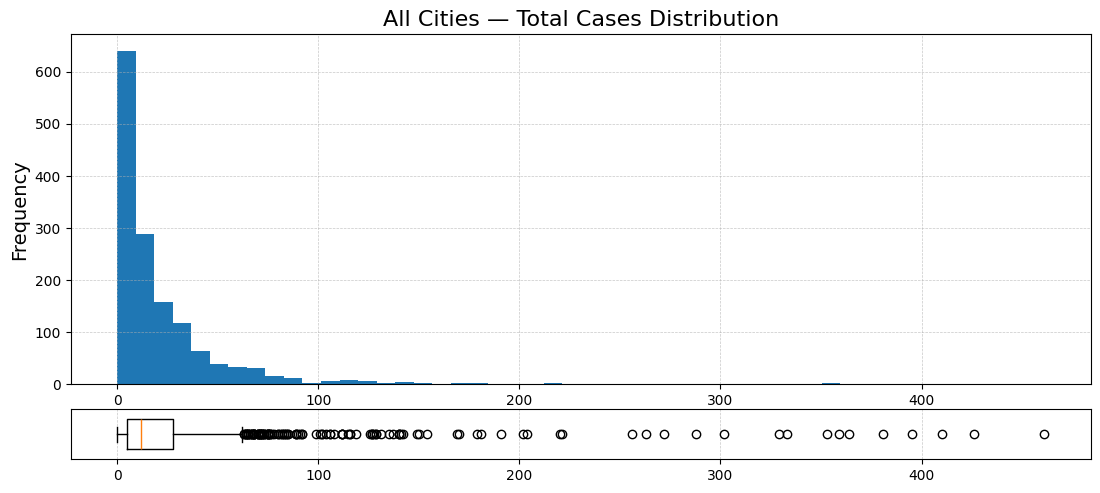

In [30]:
import matplotlib.pyplot as plt

# Grab all total_cases
data = df_merged['total_cases']

# Create a larger figure
fig = plt.figure(figsize=(12, 5))

# Main histogram axes
ax_hist = fig.add_axes([0.1, 0.25, 0.85, 0.7])
ax_hist.hist(data, bins=50)
ax_hist.set_title("All Cities — Total Cases Distribution", fontsize=16)
ax_hist.set_xlabel("Total cases", fontsize=14)
ax_hist.set_ylabel("Frequency", fontsize=14)
ax_hist.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Inset boxplot axes
ax_box = fig.add_axes([0.1, 0.1, 0.85, 0.1], sharex=ax_hist)
ax_box.boxplot(data, vert=False, widths=0.6)
ax_box.set_yticks([])
ax_box.set_xlim(ax_hist.get_xlim())
ax_box.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


In [17]:
import numpy as np
# log-transform the target variable
df_merged['cases_log1p'] = np.log1p(df_merged['total_cases'])

/tmp/ipykernel_22743/1172873759.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


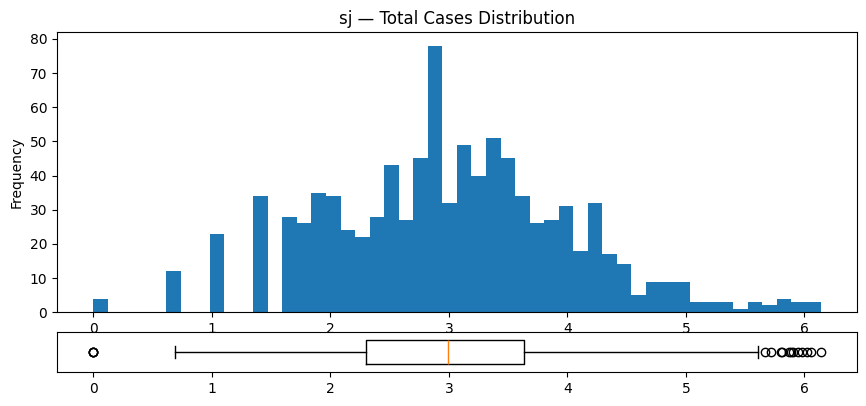

/tmp/ipykernel_22743/1172873759.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


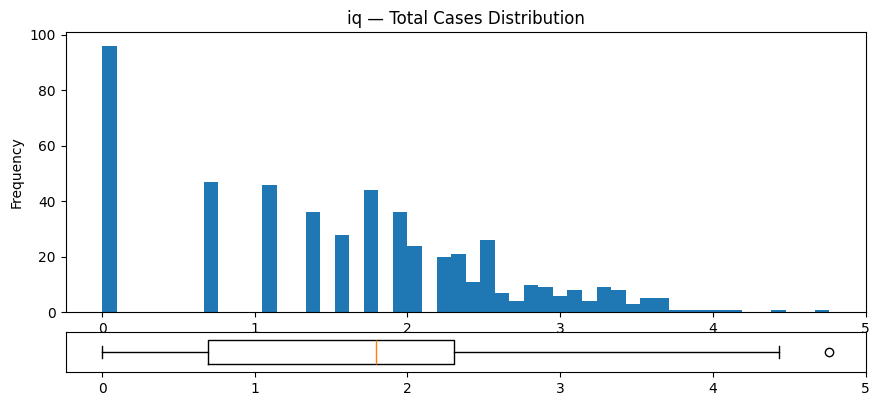

In [18]:
import matplotlib.pyplot as plt

# Make sure 'city' is treated as categorical
cities = df_merged['city'].unique()

for city in cities:
    data = df_merged.loc[df_merged['city'] == city, 'cases_log1p']

    
    # create a new figure
    fig = plt.figure(figsize=(10, 4))
    
    # main histogram axes
    ax_hist = fig.add_axes([0.1, 0.2, 0.8, 0.7])  # [left, bottom, width, height]
    ax_hist.hist(data, bins=50)
    ax_hist.set_title(f"{city} — Total Cases Distribution")
    ax_hist.set_xlabel("Total cases")
    ax_hist.set_ylabel("Frequency")
    
    # inset boxplot axes
    ax_box = fig.add_axes([0.1, 0.05, 0.8, 0.1], sharex=ax_hist)
    ax_box.boxplot(data, vert=False, widths=0.6)
    ax_box.set_yticks([])      # hide y-axis of the boxplot
    ax_box.set_xlabel("")      # you can remove xlabel here if you like
    ax_box.set_xlim(ax_hist.get_xlim())  # align x-limits with histogram
    
    plt.tight_layout()
    plt.show()

- SJ (top plot): the log1p squashes that long right‐tail nicely into a roughly bell-shaped mound.

- IQ (bottom plot): because so many weeks are zero (or very small counts) and then a handful of mid-range spikes, even the log doesn’t fully “Gaussianize” the shape.

We can use Box–Cox or Yeo–Johnson to automatically pick a power transform that best normalizes the data (Yeo–Johnson handles zeros).

/tmp/ipykernel_22743/237336510.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


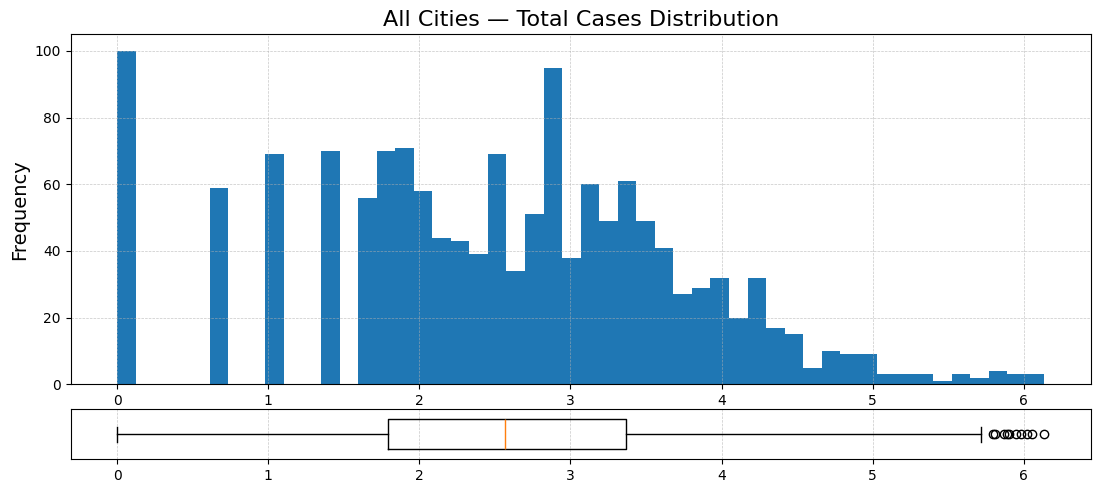

In [31]:
import matplotlib.pyplot as plt

# Grab all total_cases
data = df_merged['cases_log1p']

# Create a larger figure
fig = plt.figure(figsize=(12, 5))

# Main histogram axes
ax_hist = fig.add_axes([0.1, 0.25, 0.85, 0.7])
ax_hist.hist(data, bins=50)
ax_hist.set_title("All Cities — Total Cases Distribution", fontsize=16)
ax_hist.set_xlabel("Total cases", fontsize=14)
ax_hist.set_ylabel("Frequency", fontsize=14)
ax_hist.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Inset boxplot axes
ax_box = fig.add_axes([0.1, 0.1, 0.85, 0.1], sharex=ax_hist)
ax_box.boxplot(data, vert=False, widths=0.6)
ax_box.set_yticks([])
ax_box.set_xlim(ax_hist.get_xlim())
ax_box.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


## Correlation of Target Variable with Features

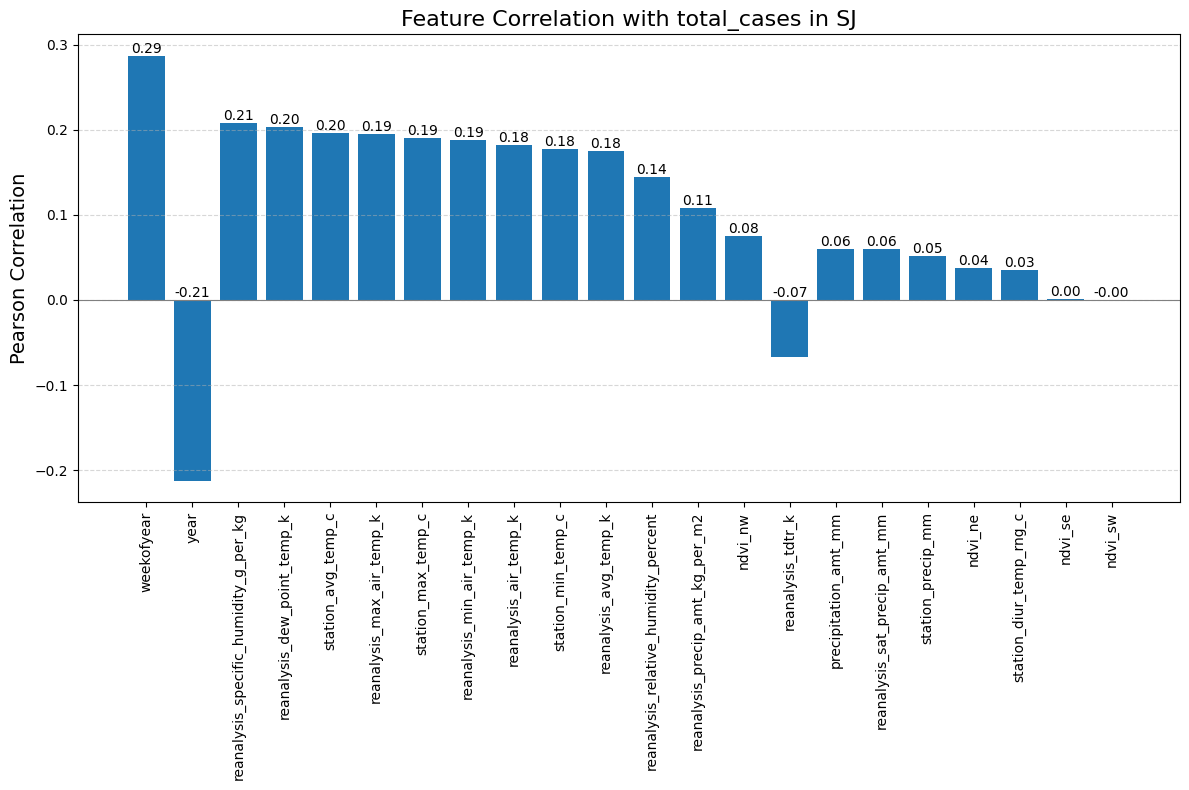

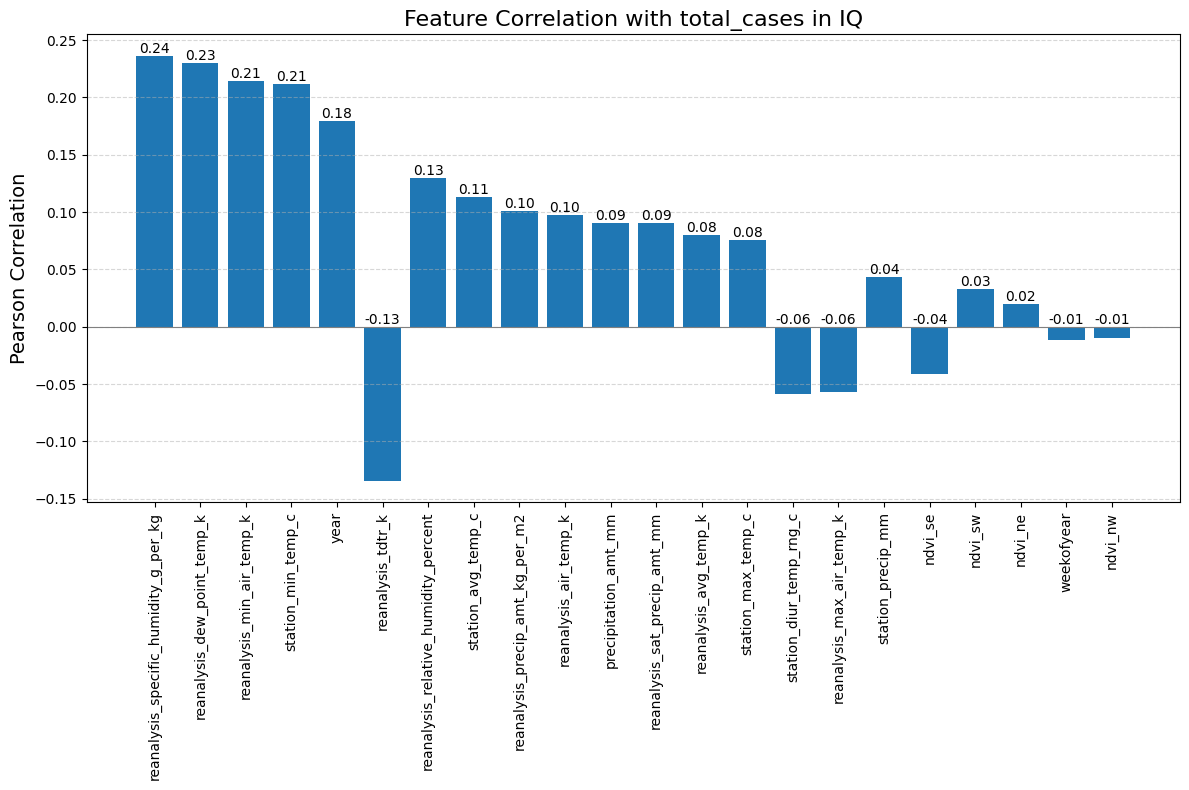

In [27]:
import matplotlib.pyplot as plt

# List input features (exclude non-numeric/ID columns)
exclude_cols = ['city', 'week_start_date', 'total_cases', 'cases_log1p']
features = [
    c for c in df_merged.columns 
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_merged[c])
]

for city in df_merged['city'].unique():
    city_df = df_merged[df_merged['city'] == city]
    corr = city_df[features + ['total_cases']].corr()['total_cases'].drop('total_cases')
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    
    plt.figure(figsize=(12, 8))
    bars = plt.bar(corr.index, corr.values)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.xticks(rotation=90)
    plt.title(f'Feature Correlation with total_cases in {city.upper()}', fontsize=16)
    plt.ylabel('Pearson Correlation', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Annotate each bar with its value
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,    # x = center of bar
            h if h >= 0 else 0,                   # y = top of bar (or 0 for negatives)
            f'{h:.2f}',                          # text = correlation
            ha='center', va='bottom', fontsize=10
        )
    
    plt.tight_layout()
    plt.show()


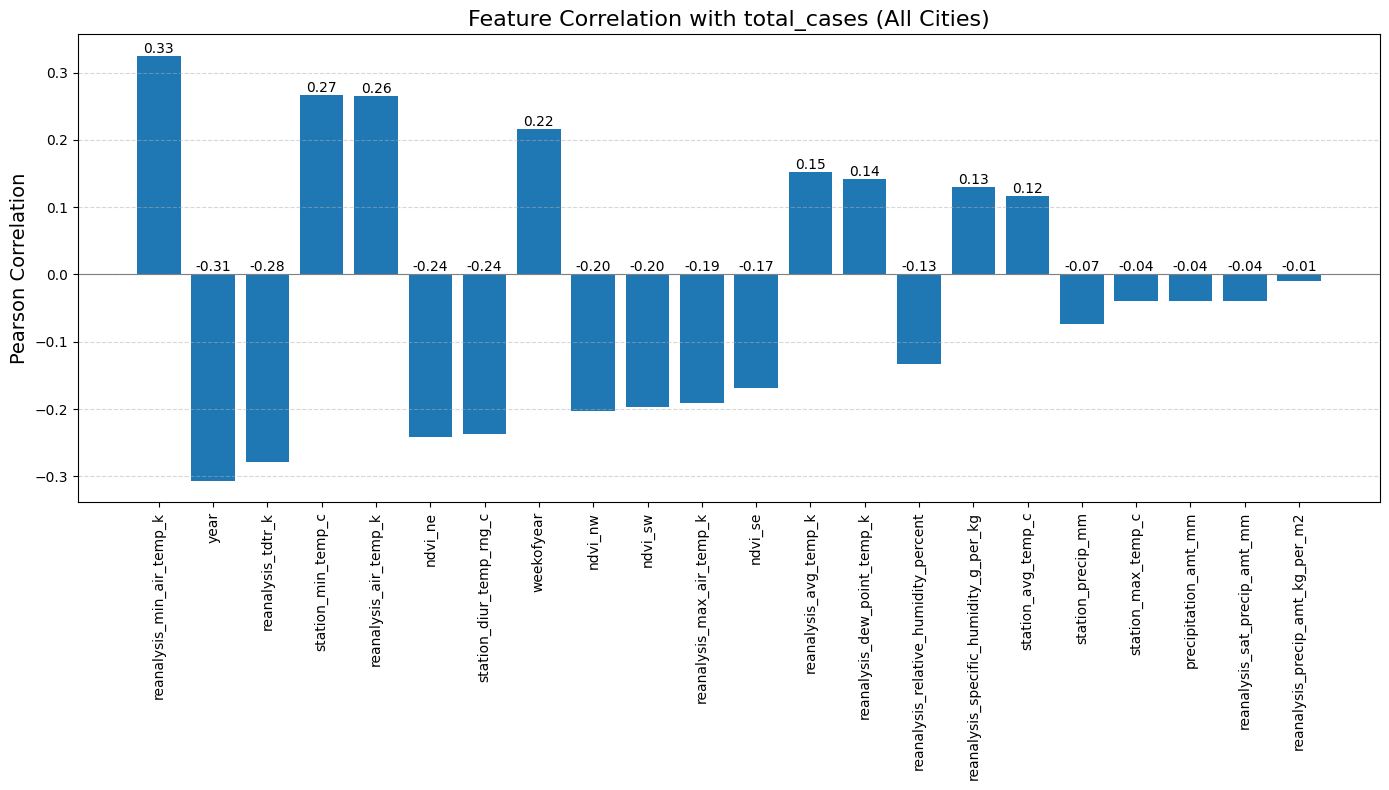

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# List input features (exclude non-numeric/ID columns)
exclude_cols = ['city', 'week_start_date', 'total_cases', 'cases_log1p']
features = [
    c for c in df_merged.columns 
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_merged[c])
]

# Compute correlations on the entire merged DataFrame
corr = df_merged[features + ['total_cases']].corr()['total_cases'].drop('total_cases')
# Sort by absolute strength
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(14, 8))
bars = plt.bar(corr.index, corr.values)
plt.axhline(0, color='grey', linewidth=0.8)
plt.xticks(rotation=90)
plt.title('Feature Correlation with total_cases (All Cities)', fontsize=16)
plt.ylabel('Pearson Correlation', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate each bar with its value
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x = center of bar
        h if h >= 0 else 0,                 # y = top of bar (or 0 for negatives)
        f'{h:.2f}',                         # text = correlation
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()


In [12]:
from sklearn.base import BaseEstimator, TransformerMixin
from typing import Union, List
import numpy as np
import pandas as pd


class CyclicTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer to encode a cyclical column (like week of year) into sine and cosine features.

    Parameters
    ----------
    column : str
        Name of the column to transform.
    period : int
        The period of the cycle (e.g., 52 for weeks in a year).
    drop_original : bool, default=True
        If True, drop the original column after transformation.
    """

    def __init__(self, column: str, period: int, drop_original: bool = True):
        self.column = column
        self.period = period
        self.drop_original = drop_original

    def fit(self, X: pd.DataFrame, y=None):
        # No fitting necessary
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        # compute angle
        angles = 2 * np.pi * X[self.column] / self.period
        # add sine and cosine columns
        X[f"{self.column}_sin"] = np.sin(angles)
        X[f"{self.column}_cos"] = np.cos(angles)
        # optionally drop original
        if self.drop_original:
            X = X.drop(columns=[self.column])
        return X.reset_index(drop=True)

In [16]:
# 1) instantiate your transformer for the 'weekofyear' cycle
cyclic = CyclicTransformer(column="weekofyear", period=52, drop_original=False)

# 2) fit & transform your merged_df in one go
merged_cyclic = cyclic.fit_transform(df_merged)

# now merged_df has two new columns: 'weekofyear_sin' and 'weekofyear_cos'
print(merged_cyclic.columns)

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases',
       'weekofyear_sin', 'weekofyear_cos'],
      dtype='object')


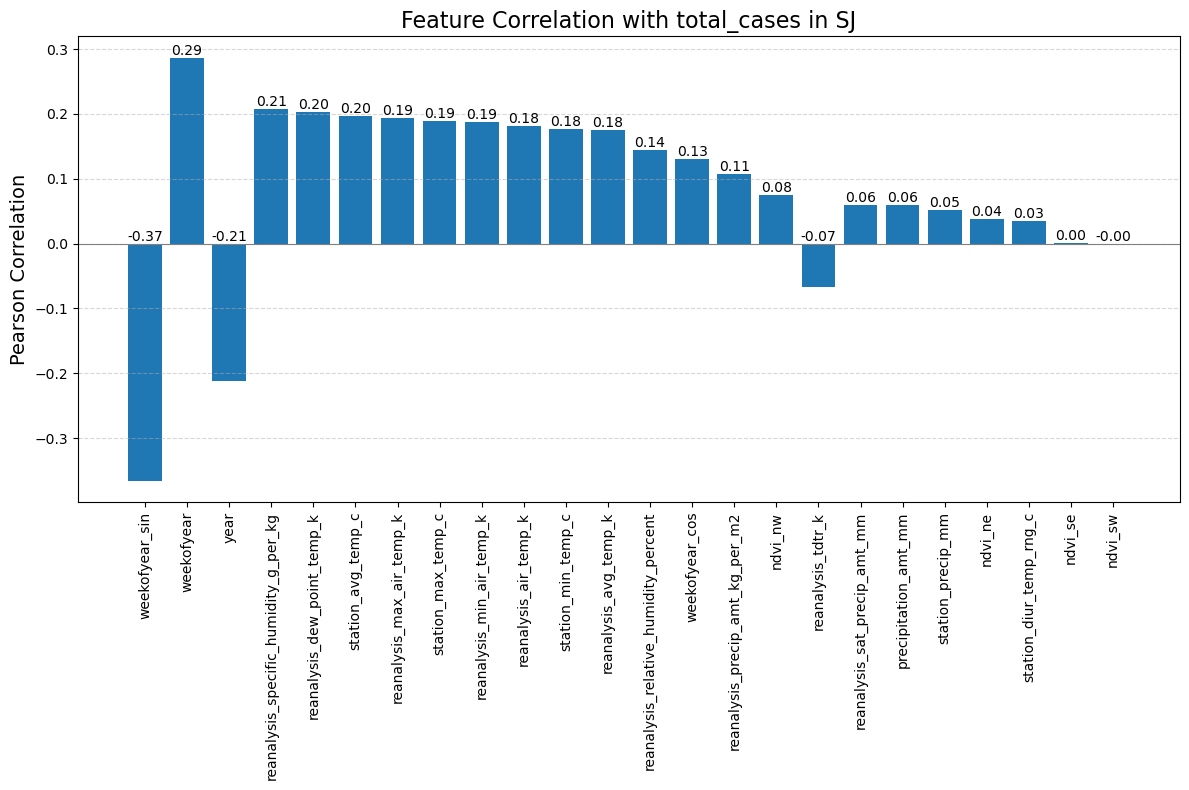

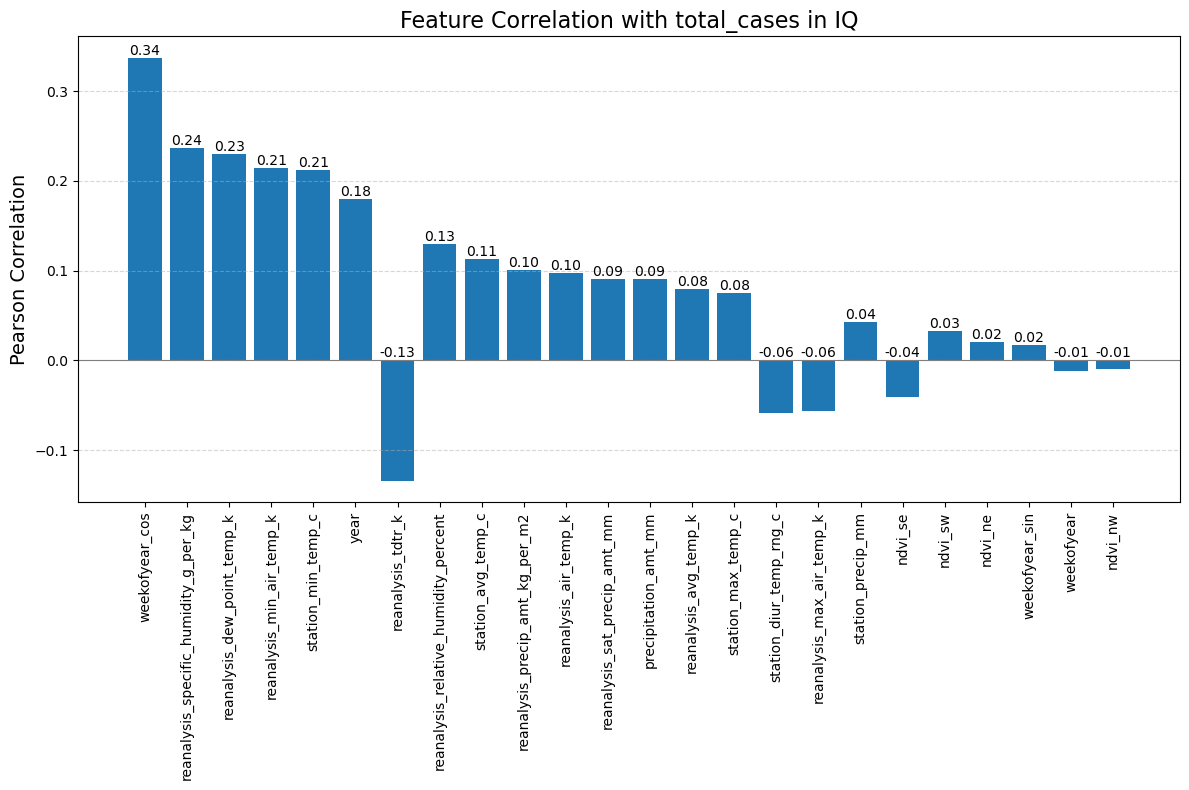

In [18]:
import matplotlib.pyplot as plt

# List input features (exclude non-numeric/ID columns)
exclude_cols = ['city', 'week_start_date', 'total_cases', 'cases_log1p']
features = [
    c for c in merged_cyclic.columns 
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(merged_cyclic[c])
]

for city in merged_cyclic['city'].unique():
    city_df = merged_cyclic[merged_cyclic['city'] == city]
    corr = city_df[features + ['total_cases']].corr()['total_cases'].drop('total_cases')
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    
    plt.figure(figsize=(12, 8))
    bars = plt.bar(corr.index, corr.values)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.xticks(rotation=90)
    plt.title(f'Feature Correlation with total_cases in {city.upper()}', fontsize=16)
    plt.ylabel('Pearson Correlation', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Annotate each bar with its value
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,    # x = center of bar
            h if h >= 0 else 0,                   # y = top of bar (or 0 for negatives)
            f'{h:.2f}',                          # text = correlation
            ha='center', va='bottom', fontsize=10
        )
    
    plt.tight_layout()
    plt.show()